# MVP - Classificação de Câncer de Mama

## Contexto do problema

Neste notebook, será desenvolvido um modelo de machine learning para classificação de tumores de mama em duas classes: benigno e maligno.

O problema será tratado como uma tarefa de classificação supervisionada. Para isso, serão realizadas as etapas de carga dos dados, análise inicial, separação entre treino e teste, transformação dos dados, treinamento de diferentes algoritmos, otimização de hiperparâmetros, avaliação comparativa e exportação do melhor modelo.

Os algoritmos avaliados serão:
- K-Nearest Neighbors (KNN)
- Árvore de Decisão
- Naive Bayes
- Support Vector Machine (SVM)

Ao final, o melhor modelo será salvo para uso posterior em uma aplicação full stack.

##Importação das bibliotecas

In [30]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

##Carga do dataset

In [31]:
url = "https://raw.githubusercontent.com/acojunior/mvp-qa/refs/heads/main/breast-cancer.csv"
df = pd.read_csv(url, delimiter=',')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Análise inicial dos dados

Nesta etapa, foi realizada uma inspeção inicial do dataset para verificar sua estrutura, os tipos de dados presentes, a existência de valores ausentes e a distribuição da variável alvo.

Também foi confirmada a necessidade de converter a variável `diagnosis` para formato numérico, a fim de permitir o treinamento dos modelos de classificação.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [33]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [34]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


## Seleção de atributos

A variável alvo do problema é `diagnosis`, que indica se o tumor é maligno (`M`) ou benigno (`B`).

Para simplificar a aplicação e reduzir a complexidade da entrada de dados no frontend, foi realizada uma seleção de atributos, mantendo apenas variáveis consideradas mais relevantes para o modelo.

Essa decisão também contribui para reduzir redundância entre features altamente correlacionadas e facilita a integração com a aplicação full stack.

In [35]:
# Features selecionadas para serem usadas
selected_features = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean'
]

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df[selected_features]
y = df['diagnosis']


## Separação entre treino e teste

Os dados foram divididos em conjuntos de treino e teste utilizando a estratégia holdout.

Foi utilizada separação estratificada para preservar a proporção entre as classes nos dois conjuntos, tornando a avaliação do modelo mais confiável.

In [36]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y
)

##Padronização e normalização

In [37]:
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

## Avaliação inicial dos modelos

Nesta etapa, foram comparados os algoritmos KNN, Árvore de Decisão, Naive Bayes e SVM em três cenários:
- dados originais
- dados padronizados
- dados normalizados

A avaliação foi realizada com validação cruzada estratificada, utilizando acurácia como métrica de comparação inicial.

KNN-orig: 0.888 (0.051)
CART-orig: 0.930 (0.033)
NB-orig: 0.923 (0.040)
SVM-orig: 0.888 (0.030)
KNN-padr: 0.945 (0.031)
CART-padr: 0.930 (0.032)
NB-padr: 0.925 (0.040)
SVM-padr: 0.941 (0.032)
KNN-norm: 0.947 (0.031)
CART-norm: 0.939 (0.037)
NB-norm: 0.925 (0.040)
SVM-norm: 0.945 (0.033)


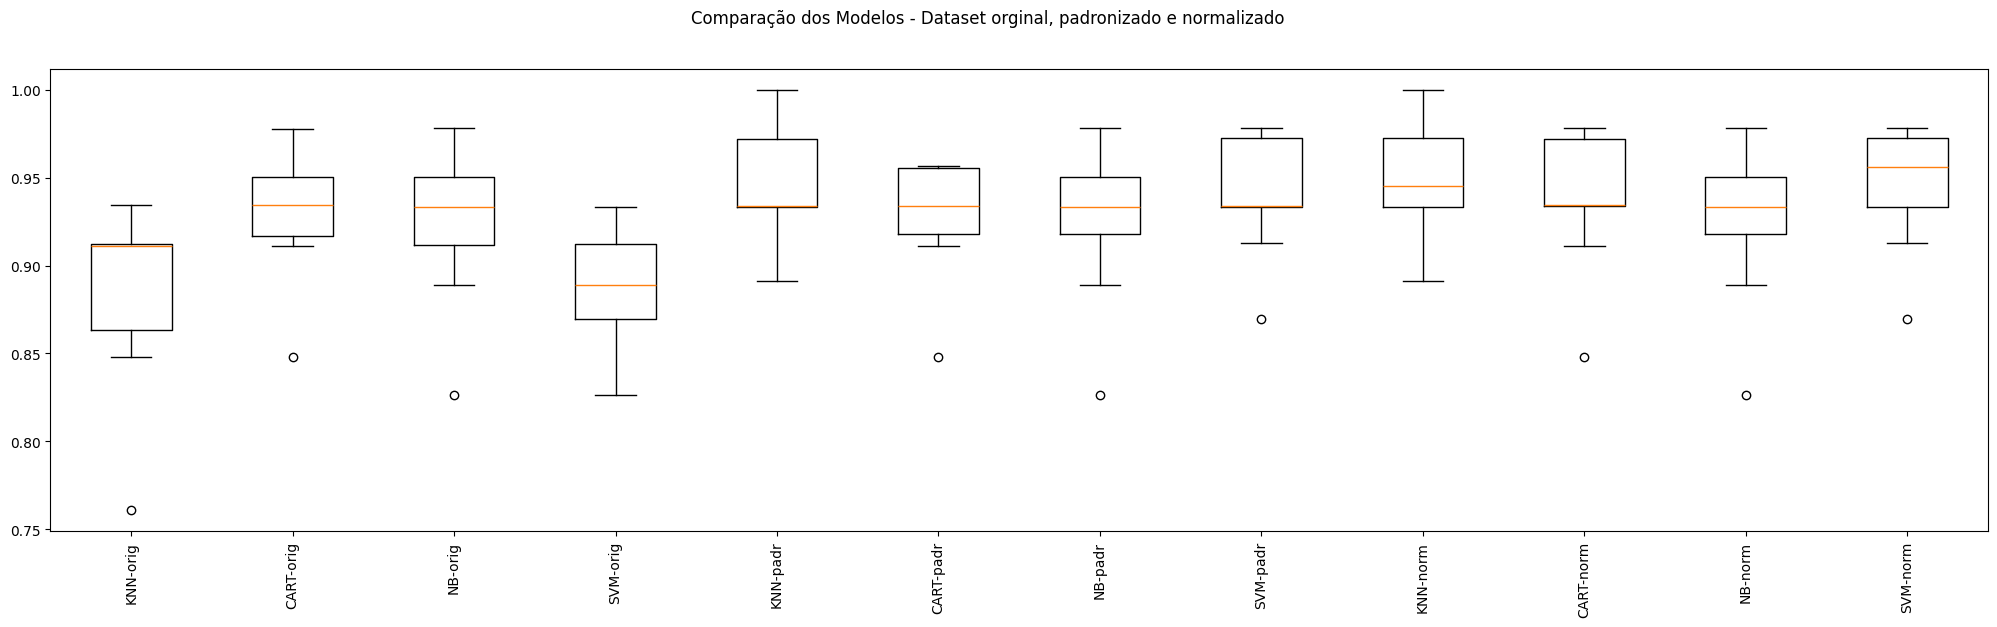

In [38]:
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())


# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

O modelo KNN com dados normalizados apresentou o melhor desempenho médio (0.947), com baixa variabilidade, indicando boa estabilidade.

Observa-se que modelos baseados em distância, como KNN e SVM, apresentaram melhora significativa após a aplicação de técnicas de escala (padronização e normalização), enquanto modelos como Árvore de Decisão e Naive Bayes não foram significativamente impactados.

Apesar do KNN apresentar o melhor resultado, a diferença para o SVM normalizado é pequena, indicando que ambos os modelos são boas opções para o problema.

Mas antes de decidir o melhor modelo, vou aplicar a otimização de hiperparâmetros

## Otimização de hiperparâmetros

Após a comparação inicial, foram selecionados os modelos mais promissores para a etapa de otimização de hiperparâmetros.

A otimização foi realizada com GridSearchCV, buscando identificar as combinações de parâmetros que proporcionassem o melhor desempenho médio em validação cruzada.

In [39]:
# Tuning do KNN

pipelines = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
svm = ('SVM', SVC())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

param_grid_knn = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

param_grid_svm = {
    'SVM__C': [0.1, 1, 10],
    'SVM__kernel': ['linear', 'rbf']
}

pipelines.append(('knn-orig', Pipeline(steps=[knn]), param_grid_knn))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn]), param_grid_knn))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn]), param_grid_knn))

pipelines.append(('svm-orig', Pipeline(steps=[svm]), param_grid_svm))
pipelines.append(('svm-padr', Pipeline(steps=[standard_scaler, svm]), param_grid_svm))
pipelines.append(('svm-norm', Pipeline(steps=[min_max_scaler, svm]), param_grid_svm))

# Prepara e executa o GridSearchCV
for name, model, param_grid in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("%s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

knn-orig - Melhor: 0.898986 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 9}
knn-padr - Melhor: 0.953961 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 11}
knn-norm - Melhor: 0.958357 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 13}
svm-orig - Melhor: 0.918599 usando {'SVM__C': 10, 'SVM__kernel': 'linear'}
svm-padr - Melhor: 0.942850 usando {'SVM__C': 0.1, 'SVM__kernel': 'rbf'}
svm-norm - Melhor: 0.945169 usando {'SVM__C': 1, 'SVM__kernel': 'rbf'}


## Resultado da otimização de hiperparâmetros

Após a otimização dos hiperparâmetros com GridSearchCV, o melhor desempenho foi obtido pelo modelo KNN com normalização dos dados, alcançando score médio de 0.958357.

A melhor configuração encontrada para esse modelo foi:
- métrica de distância: manhattan
- número de vizinhos: 13

## Avaliação final do melhor modelo

Após a otimização de hiperparâmetros, o modelo KNN com normalização foi selecionado como melhor candidato.

Nesta etapa, o modelo é treinado no conjunto de treino e avaliado no conjunto de teste, permitindo observar seu desempenho em dados não vistos.

In [40]:
# Preparação do modelo
scaler = MinMaxScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

model = KNeighborsClassifier(metric='manhattan', n_neighbors=13)
model.fit(rescaledX, y_train)

# Avaliação no conjunto de teste
rescaledTestX = scaler.transform(X_test)
predictions = model.predict(rescaledTestX)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))
print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.9035087719298246

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93        72
           1       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114


Matriz de Confusão:

[[70  2]
 [ 9 33]]


In [41]:
# Preparação do modelo com TODO o dataset
scaler = MinMaxScaler().fit(X) # ajuste do scaler com TODO o dataset
rescaledX = scaler.transform(X) # aplicação da normalização com TODO o dataset
model.fit(rescaledX, y)

KNeighborsClassifier(metric='manhattan', n_neighbors=13)

## Análise dos resultados finais

O modelo selecionado apresentou desempenho médio superior durante a validação cruzada em comparação com a avaliação final no conjunto de teste.

Essa diferença sugere a presença de um leve overfitting, já que o desempenho em validação foi mais alto do que em dados não vistos. Ainda assim, o modelo final apresentou desempenho satisfatório e pode ser considerado adequado para o problema proposto.

Também foi possível observar que algoritmos sensíveis à escala dos dados, como KNN e SVM, apresentaram melhora significativa após padronização ou normalização, enquanto a Árvore de Decisão e o Naive Bayes foram menos impactados por essas transformações.

## Exportação do modelo

Para facilitar a integração com a aplicação full stack, o modelo final foi exportado juntamente com a etapa de normalização, garantindo que o backend possa realizar predições diretamente a partir dos dados brutos informados pelo usuário.

In [42]:
import joblib
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', KNeighborsClassifier(metric='manhattan', n_neighbors=13))
])

final_model.fit(X, y)

joblib.dump(final_model, 'melhor_modelo.pkl')

['melhor_modelo.pkl']

In [43]:
from google.colab import files
files.download('melhor_modelo.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusão

Neste notebook foi desenvolvido um modelo de machine learning para classificação de tumores de mama em benignos e malignos.

Foram realizadas as etapas de carga dos dados, análise inicial, seleção de atributos, separação entre treino e teste, transformação dos dados, treinamento e comparação de diferentes algoritmos, otimização de hiperparâmetros, avaliação final e exportação do modelo escolhido.

Os melhores resultados foram obtidos pelo modelo KNN com normalização dos dados, utilizando distância Manhattan e 13 vizinhos. Embora o desempenho médio em validação cruzada tenha sido superior ao desempenho observado no conjunto de teste, o modelo final apresentou desempenho satisfatório e foi considerado adequado para o problema proposto.

A redução do número de atributos também contribuiu para simplificar a futura integração com a aplicação full stack, reduzindo a quantidade de dados necessários para a realização das predições.